In [1]:
# Import necessary packages
import glitterin

In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/constants.py"

/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/glitterin/glitterin_env/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/glitterin/glitterin_env/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/glitterin/glitterin_env/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/glitterin/glitterin_env/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [3]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions_glitterin"

In [4]:
def make_simple_plot(xlabel, ylabel,
                     title,
                     axis_label_fs = 25,
                     axis_num_fs = 20,
                     title_fs = 20,
                     text_fs = 15,
                     legend_text_fs = 20):
    
    # Plot the data
    fig, ax = plt.subplots(figsize=(10,7))
    
    
    # Set axis labels and title
    ax.set_xlabel(xlabel, fontsize = axis_label_fs)
    ax.set_ylabel(ylabel, fontsize = axis_label_fs)
    ax.set_title(title,   fontsize = title_fs)
    
    # Format the axes how I want the,
    plt.tick_params(axis="x", which="major", direction="in", bottom=True, length=7, labelsize = axis_num_fs)
    plt.tick_params(axis="y", which="major", direction="in", bottom=True, length=7, labelsize = axis_num_fs)

    
    
    return fig, ax

In [5]:
bands = ["Band 4 nterms2", "Band 5", "Band 6", "Band 7 nterms2"]

# glitterin

In [6]:
# Make the path to the neural network models 
nndir = "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/glitterin/nnmodels/"

# This producer is an object that can compute scattering properties using the neural network models in 
# the nndir folder 

# Create the scattering wrapper
producer = glitterin.user.ScatteringProducer(nndir=nndir)

# Run the producer
producer.setup(['Z11', 'Z12', 'albedo'])

Loaded model for ems
Loaded model for N12
Loaded model for Qext
Loaded model for N11


/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/glitterin/glitterin_env/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## Inputs for arrays

In [7]:
wavelength_cm = {f'{b}': micron_to_cm(lambda_mm[b]) for b in bands}

wavelength_cm

{'Band 4 nterms2': np.float64(0.0002),
 'Band 5': np.float64(0.00017),
 'Band 6': np.float64(0.00013000000000000002),
 'Band 7 nterms2': np.float64(8.7e-05)}

In [8]:
a_max_cm = micron_to_cm([10, 100, 1000, 10000])

labels = ['10 $\mu$m', '100 $\mu$m', '1 mm', '1 cm']

a_max_cm

array([0.001, 0.01 , 0.1  , 1.   ])

In [9]:
x = {b: (2 * np.pi * a_max_cm) / wavelength_cm[b] for b in bands}

x

{'Band 4 nterms2': array([   31.41592654,   314.15926536,  3141.59265359, 31415.9265359 ]),
 'Band 5': array([   36.95991357,   369.59913572,  3695.99135716, 36959.91357164]),
 'Band 6': array([   48.33219467,   483.32194671,  4833.21946706, 48332.19467061]),
 'Band 7 nterms2': array([   72.22052077,   722.20520772,  7222.05207722, 72220.52077218])}

In [10]:
# Set the inputs
n = np.array([1.5])              # Refractive index m = n + ik 
k = np.array([0.01])
theta = np.linspace(0, 180, 181) # Scatting angles 

results = {
    b: [
        producer(np.array([x[b][i]]),
                 n,
                 k,
                 theta,
                 wavelength_cm[b],
                 xtype='vol',
                 outtype='dict')
        for i in range(len(a_max_cm))
    ]
    for b in bands
}

In [11]:
Z11 = {
    b: [
        results[b][i]['Z11']
        for i in range(len(a_max_cm))
    ]
    for b in bands
}


Z12 = {
    b: [
        results[b][i]['Z12']
        for i in range(len(a_max_cm))
    ]
    for b in bands
}


omega = {
    b: [
        results[b][i]['albedo']
        for i in range(len(a_max_cm))
    ]
    for b in bands
}


P_eff = {
    b: [
        -Z12[b][i] / Z11[b][i]
        for i in range(len(a_max_cm))
    ]
    for b in bands
}


P_times_omega = {
    b: [
        (Z12[b][i] / Z11[b][i]) * omega[b][i]
        for i in range(len(a_max_cm))
    ]
    for b in bands
}


# Plot the scatting angle in degrees vs -$Z_{12}/Z_{11}$

Figure 2

https://ui.adsabs.harvard.edu/abs/2016ApJ...820...54K/abstract

In [12]:
fig2_labels = ['10 $\mu$m', '100 $\mu$m', '1 mm', '1 cm']

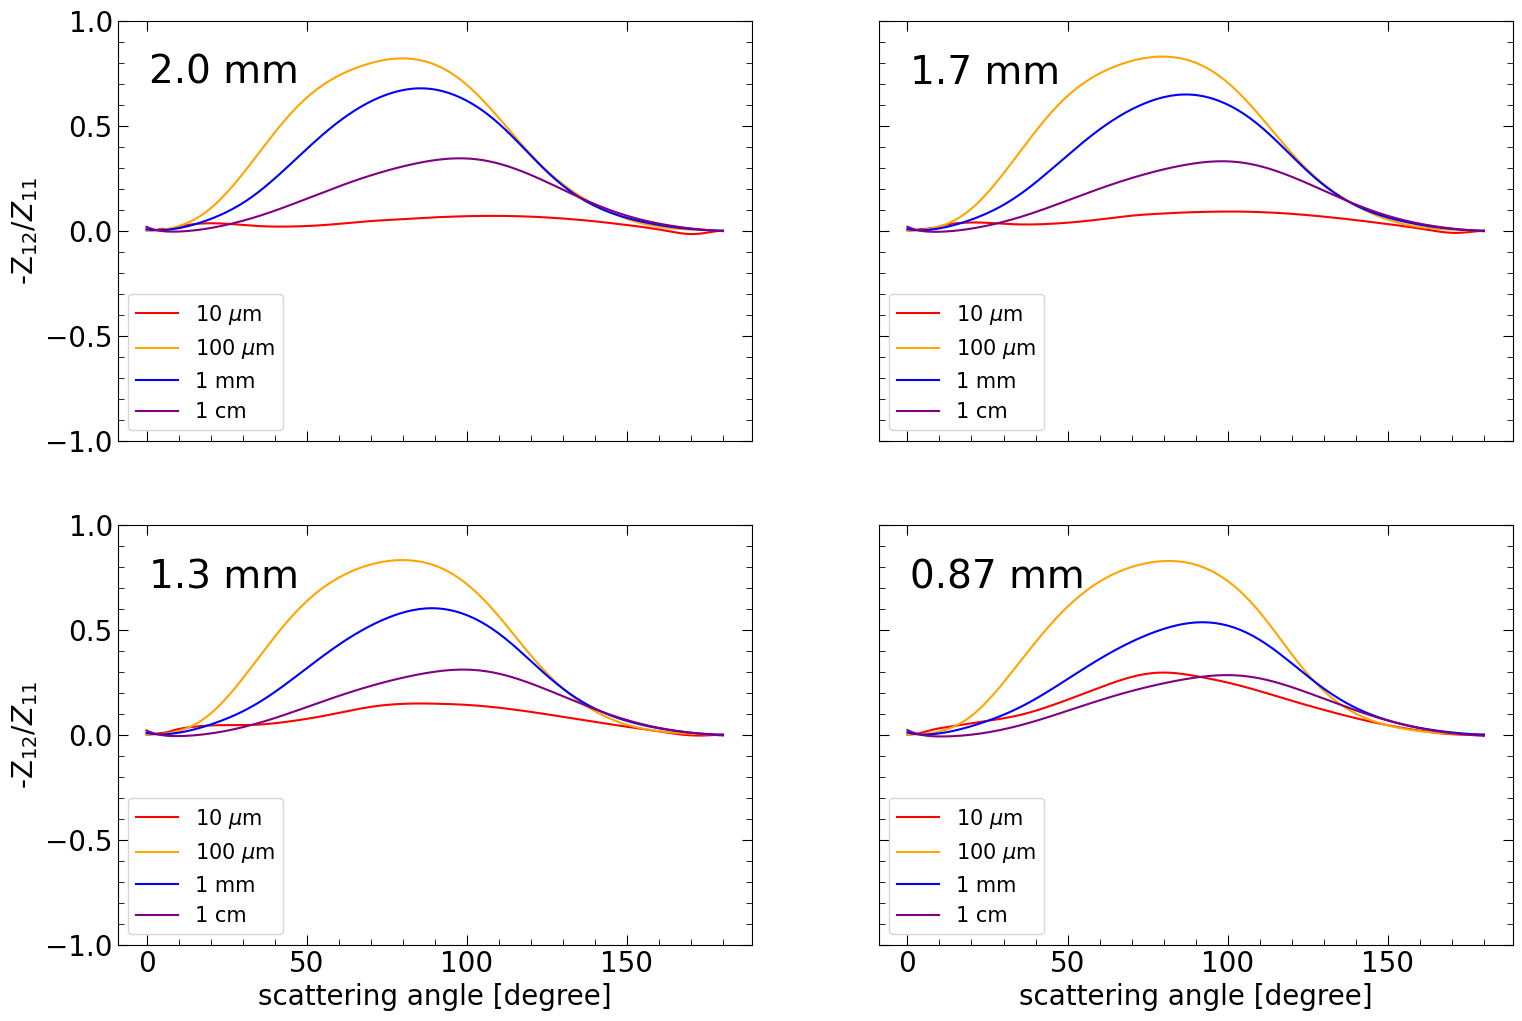

In [13]:
# Plotting
fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharex = True, sharey = True)

# Adjust ticks
for i, (ax, b) in enumerate(zip(axes.flat, bands)):
    
    # Plot the data 
    # --------------------------------------------------------------------
    # Loop over each a_max_cm
    for j, a in enumerate(a_max_cm):
        ax.plot(theta, P_eff[b][j], color = kataoka_fig2_colors[j], label = labels[j])
    # --------------------------------------------------------------------
    
    
    # Set axis labels
    # --------------------------------------------------------------------
    if i in (0, 2):
        ax.set_ylabel('-Z$_{12}/Z_{11}$', fontsize = axis_label_fs)
    
    if i in (2, 3):
        ax.set_xlabel('scattering angle [degree]', fontsize = axis_label_fs)
    # --------------------------------------------------------------------
    
    # Axis ticks
    ax.minorticks_on()
    
    ax.tick_params(axis="x", which="minor", direction="in", left=True, right=True, length=4)
    ax.tick_params(axis="y", which="minor", direction="in", left=True, right=True, length=4)


    ax.tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
    ax.tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)

    # Add a legend
    ax.legend(fontsize = legend_text_fs, loc = 'lower left')
    
    # Set y-lim
    ax.set_ylim(-1, 1)
    
    ax.text(0.05, 0.85,
           f"{constants.lambda_mm[bands[i]]} mm",
           transform=ax.transAxes,
           fontsize=text_fs)

## Figure 3 — P vs a_max (at θ = 90°)

https://ui.adsabs.harvard.edu/abs/2016ApJ...820...54K/abstract


In [20]:
N_grains = 200

a_max_dist_micron = np.logspace(0, 4, N_grains)

a_max_dist_cm = micron_to_cm(a_max_dist_micron)

In [15]:
x = {
    b: (2 * np.pi * a_max_dist_cm) / wavelength_cm[b]
    for b in bands
}

# --- Run glitterin ---
results = {
    b: producer(x[b],
                np.full_like(x[b], n[0]),
                np.full_like(x[b], k[0]),
                theta,
                wavelength_cm[b],
                xtype='vol',
                outtype='dict')
    for b in bands
}

# --- Extract Mueller matrix ---
Z11 = {b: results[b]['Z11'] for b in bands}
Z12 = {b: results[b]['Z12'] for b in bands}

# --- Compute polarization ---
P = {b: -Z12[b] / Z11[b] for b in bands}

# --- Extract theta = 90° ---
theta_idx = np.argmin(np.abs(theta - 90))

P_90 = {
    b: P[b][theta_idx, :]
    for b in bands
}

# --- Albedo ---
omega = {b: results[b]['albedo'] for b in bands}

# --- Compute P * omega at 90° ---
P_times_omega_90 = {
    b: P_90[b] * omega[b]
    for b in bands
}

P_vs_amax = {
    b: P[b][theta_idx, :]
    for b in bands
}

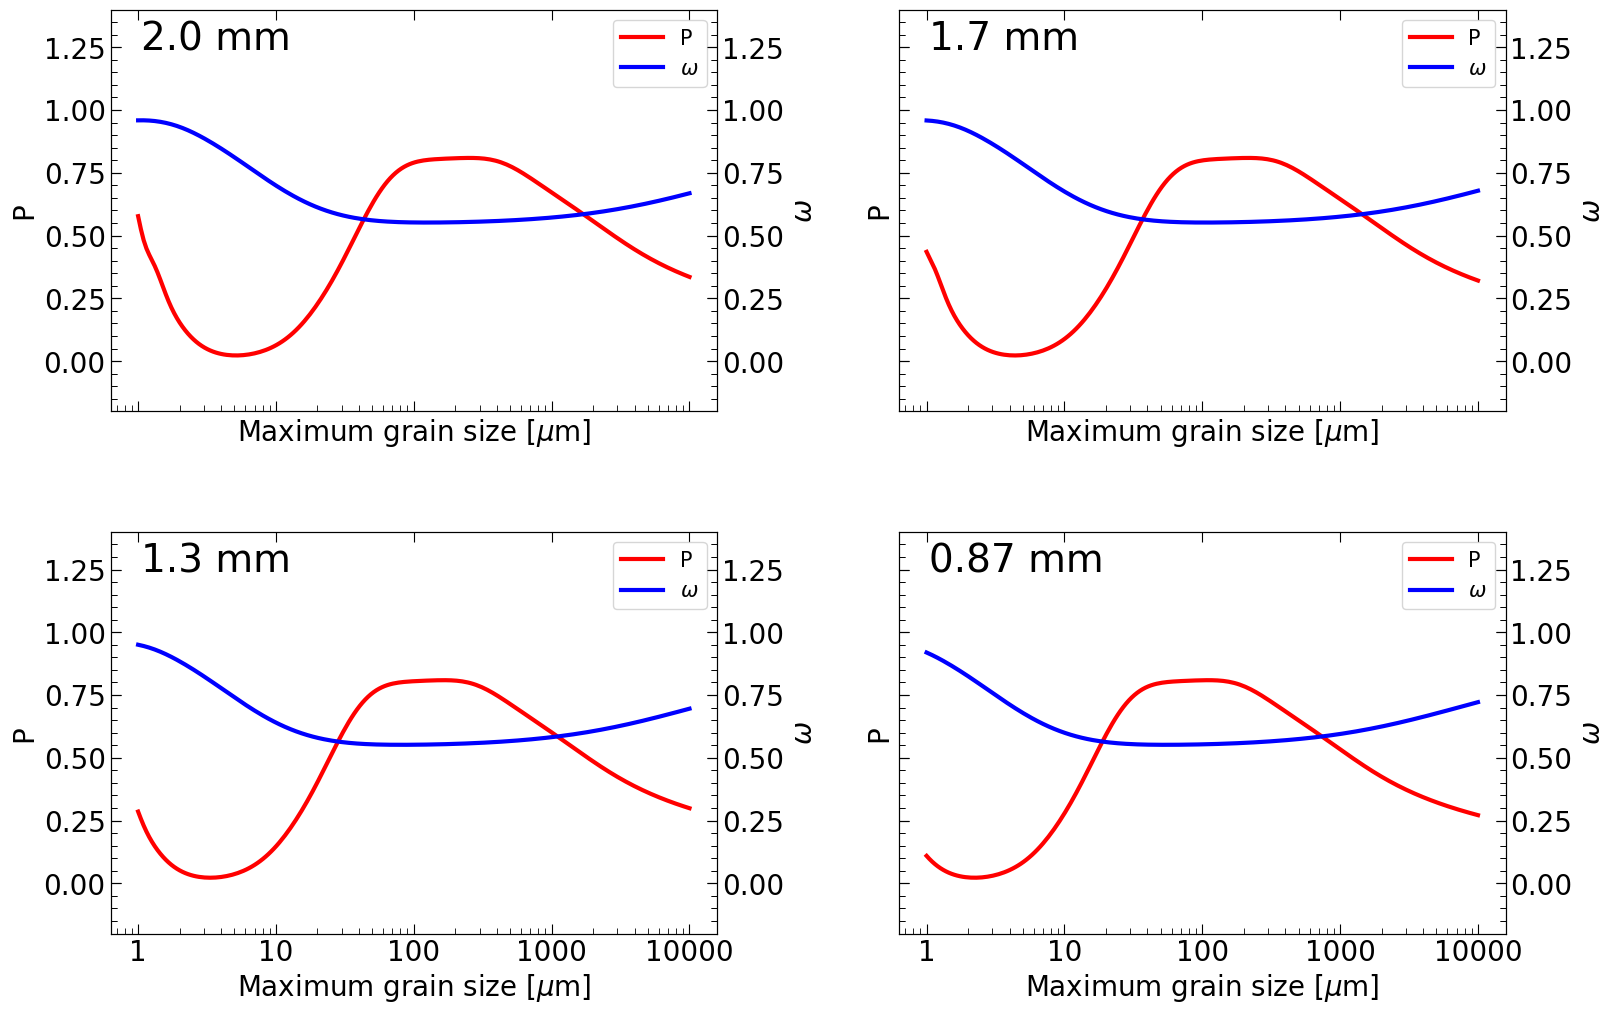

In [16]:
# Plotting
fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharex=True, sharey = True)
axes = axes.flatten()  # makes indexing easier

# Store twin axes
axes2 = []

for i, b in enumerate(bands):

    ax = axes[i]
    ax2 = ax.twinx()
    axes2.append(ax2)

    line_P, = ax.plot(a_max_dist_micron,
                      P_vs_amax[b],
                      color='red',
                      label='P',
                      lw=3)

    line_omega, = ax2.plot(a_max_dist_micron,
                           omega[b],
                           color='blue',
                           label=r'$\omega$',
                           lw=3)

    # --- Labels ---
    ax.set_xlabel('Maximum grain size [$\mu$m]', fontsize=axis_label_fs)
    ax.set_ylabel('P', fontsize=axis_label_fs)
    ax2.set_ylabel(r'$\omega$', fontsize=axis_label_fs)

    # --- Scales ---
    ax.set_xscale('log')

    # Remove scientific notation
    ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=False))
    ax.ticklabel_format(style='plain', axis='x')

    # --- Text label (wavelength) ---
    ax.text(0.05, 0.90,
            f"{constants.lambda_mm[b]} mm",
            transform=ax.transAxes,
            fontsize=text_fs)

    # --- Limits ---
    ax.set_ylim(-0.2, 1.4)
    ax2.set_ylim(-0.2, 1.4)

    # --- Legend ---
    ax.legend(handles=[line_P, line_omega],
              fontsize=legend_text_fs,
              loc='upper right')

# --- Tick styling ---
for ax in list(axes) + axes2:
    ax.minorticks_on()
    ax.tick_params(axis="x", which="minor", direction="in", left=True, right=True, length=4)
    ax.tick_params(axis="y", which="minor", direction="in", left=True, right=True, length=4)

    ax.tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
    ax.tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)

# --- Layout ---
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

## Figure 4
https://ui.adsabs.harvard.edu/abs/2016ApJ...820...54K/abstract

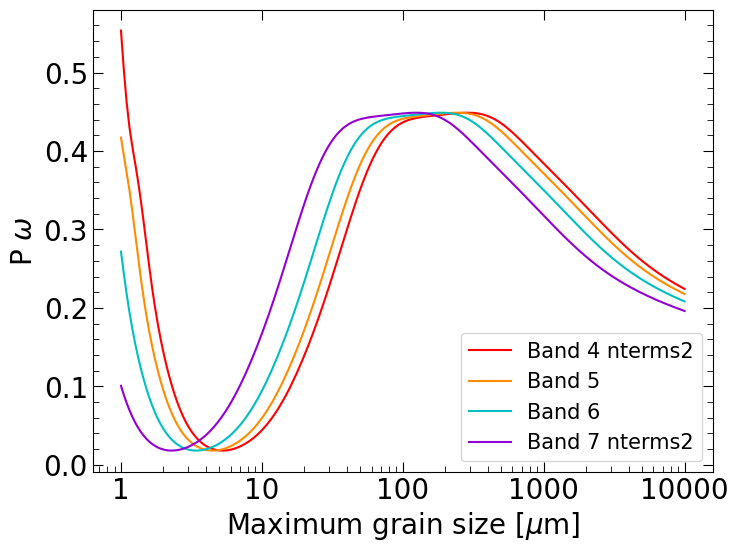

In [19]:
# mm

# Create a figure with the WCS projection
fig, ax = plt.subplots(figsize=(8, 6))
#                [B4,  B6,   B7]
# P_scale_factor = [1.15, 1.68, 1.2]

for i, b in enumerate(bands):
    ax.plot(a_max_dist_micron,
            P_times_omega_90[b],
            color = alma_band_colors[b],
            ls = '-',
            label = f'{bands[i]}')


# Add axis labels
ax.set_xlabel('Maximum grain size [$\mu$m]', fontsize=axis_label_fs)
ax.set_ylabel('P $\omega$', fontsize=axis_label_fs)


# Adjust ticks
ax.minorticks_on()

ax.tick_params(axis="x", which="minor", direction="in", left=True, right=True, length=4)
ax.tick_params(axis="y", which="minor", direction="in", left=True, right=True, length=4)
    
ax.tick_params(axis="x", which="major", direction="in", bottom=True, top=True,   length=7, labelsize=axis_num_fs)
ax.tick_params(axis="y", which="major", direction="in", left=True,   right=True, length=7, labelsize=axis_num_fs)



# Make axes log if needed
ax.set_xscale('log')
# ax.set_yscale('log')

# Remove scientific notation from x-axis
ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=False))
ax.ticklabel_format(style='plain', axis='x')

# ---------------------------------------------------------------------------------
ax.legend(fontsize = legend_text_fs)
# ---------------------------------------------------------------------------------


# ax.set_xlim(10, 1000)

